In [24]:
from econdatapy import read
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

In [9]:
weekly = pd.read_parquet('../data/processed/weekly.parquet')

In [7]:
usdzar = read.dataset(
  id = "MARKET_RATES",
  version = "1.0.0",
  series_key = "EXCX135.B.A",
  release = "ZARIBOR & ZARONIA")

usdzar_data = usdzar['data']
df = usdzar_data['EXCX135.B.A'].copy()

# Parse dates and set as index
df['TIME_PERIOD'] = pd.to_datetime(df['TIME_PERIOD'])
df = df.set_index('TIME_PERIOD').sort_index()

df = df.loc['2010-12-24':]

price = df['OBS_VALUE'].dropna()

Fetching dataset(s) - MARKET_RATES

Processing data set: ECONDATA-MARKET_RATES-1.0.0



In [12]:
weekly

,usdzar,gold,sa_3m,sa_10y,dxy,vix,us_3m,brent,baa,us_10y,platinum,log_usdzar,d4_log_gold,d4_log_platinum,d4_log_brent,d4_log_dxy,d4_vix,d4_credit,rate_spread,mr_gap
friday,,,,,,,,,,,,,,,,,,,,
2010-12-24,6.7407,1380.500,5.55,8.38,91.3013,16.47,0.14,93.63,6.11,3.41,1728.0,1.908164,0.014410,0.052878,0.099291,-0.005613,-5.75,-0.37,5.41,-0.082518
2010-12-31,6.6224,1407.875,5.55,8.28,90.5146,17.75,0.12,93.23,5.98,3.30,1755.0,1.890458,0.007307,0.021308,0.028064,-0.004016,-0.26,-0.34,5.43,-0.098161
2011-01-07,6.8110,1362.500,5.53,8.24,91.0001,17.14,0.14,94.25,6.07,3.34,1735.0,1.918539,-0.014663,0.036389,0.051265,-0.003105,-0.47,-0.06,5.39,-0.068432
2011-01-14,6.8268,1368.125,5.55,8.49,90.0461,15.46,0.15,97.86,6.09,3.35,1817.0,1.920856,-0.002555,0.068914,0.071470,-0.016624,-0.65,0.01,5.40,-0.064513
2011-01-21,7.0621,1343.750,5.56,8.70,89.7204,18.47,0.16,96.84,6.12,3.44,1817.0,1.954742,-0.026982,0.050222,0.033709,-0.017467,2.00,-0.02,5.40,-0.029347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-12,16.2682,4204.500,6.99,8.77,119.5073,17.68,3.78,88.64,6.01,4.48,1716.0,2.789212,-0.076920,-0.142596,-0.251264,0.001883,-0.75,-0.09,3.21,-0.042371
2026-06-19,16.4775,4157.725,6.99,8.58,120.3958,16.78,3.83,80.46,5.97,4.46,1664.0,2.801996,-0.081468,-0.143101,-0.284134,0.009254,0.08,-0.06,3.16,-0.027858
2026-06-26,16.4550,4060.000,6.99,8.49,120.8866,18.41,3.83,70.16,5.94,4.38,1615.0,2.800629,-0.110830,-0.170905,-0.280530,0.016753,3.09,-0.01,3.16,-0.027646


In [22]:
price = weekly['usdzar']
macro_weekly = weekly.drop(columns=['usdzar', 'log_usdzar'])

In [13]:
# Every Friday from 2021-2025 is a forecast origin
origins = pd.date_range('2021-01-01', '2025-12-01', freq='W-FRI')
horizon_offset = pd.DateOffset(months=1)  # still "1 month ahead" in calendar terms

# Refit Lasso annually, also anchored to a Friday
refit_points = pd.date_range('2021-01-01', '2025-01-01', freq='YS').map(
    lambda d: d + pd.offsets.Week(weekday=4)  # snap to the nearest Friday on/after Jan 1
)

In [14]:
def rw_drift_forecast(train_price, horizon_weeks):
    """train_price must already be weekly (e.g. resampled W-FRI)."""
    log_returns = np.log(train_price / train_price.shift(1)).dropna()
    mu = log_returns.mean()      # weekly drift
    last_price = train_price.iloc[-1]
    forecast = last_price * np.exp(mu * horizon_weeks)
    return forecast, mu

In [15]:
def build_features(feature_df, up_to_date):
    """
    feature_df: your merged macro/technical dataframe (interest_diff, gold_usd, vix, rsi, etc.)
                indexed by date, already aligned to price's frequency.
    Returns X (features) available strictly up to `up_to_date` (no lookahead).
    """
    return feature_df.loc[:up_to_date]

In [16]:
def build_residual_training_set(cutoff_date, price, macro_weekly, horizon_offset,
                                  start_date='2010-12-24'):
    """
    price and macro_weekly must both already be resampled to W-FRI frequency
    before being passed in here.
    """
    hist_origins = pd.date_range(start_date, cutoff_date, freq='W-FRI')
    resid_rows = []

    for h_origin in hist_origins:
        h_train = price.loc[:h_origin]
        if len(h_train) < 8:  # need at least ~2 months of weekly obs to estimate mu/sigma
            continue

        h_target_est = h_origin + horizon_offset
        h_future = price.loc[h_target_est:]
        if h_future.empty:
            continue
        h_actual_date = h_future.index[0]
        h_actual_value = h_future.iloc[0]

        # Count weekly steps between origin and actual target (not calendar days)
        h_horizon_weeks = price.loc[h_origin:h_actual_date].shape[0] - 1
        if h_horizon_weeks <= 0:
            continue

        h_rw_forecast, _ = rw_drift_forecast(h_train, h_horizon_weeks)
        residual = h_actual_value - h_rw_forecast

        feat_row = build_features(macro_weekly, h_origin).iloc[-1]
        resid_rows.append({**feat_row.to_dict(), 'residual': residual, 'origin': h_origin})

    return pd.DataFrame(resid_rows).set_index('origin')

In [25]:
fitted_models = {}  # refit_date -> (scaler, lasso_model)

for refit_date in refit_points:
    # Expanding window: train on everything from 2010 up to (just before) this refit date
    cutoff = refit_date - pd.DateOffset(days=1)
    resid_df = build_residual_training_set(cutoff, price, macro_weekly, horizon_offset)

    if len(resid_df) < 20:
        print(f"Skipping refit at {refit_date.date()}: insufficient history ({len(resid_df)} rows)")
        continue

    X_train = resid_df.drop(columns='residual')
    y_train = resid_df['residual']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=42).fit(X_train_scaled, y_train)

    fitted_models[refit_date] = (scaler, lasso)
    print(f"Refit at {refit_date.date()}: trained on {len(resid_df)} obs, "
          f"non-zero coefs: {np.sum(lasso.coef_ != 0)}/{len(lasso.coef_)}")

Refit at 2021-01-08: trained on 517 obs, non-zero coefs: 4/18
Refit at 2022-01-07: trained on 569 obs, non-zero coefs: 4/18
Refit at 2023-01-06: trained on 621 obs, non-zero coefs: 0/18
Refit at 2024-01-05: trained on 673 obs, non-zero coefs: 0/18
Refit at 2025-01-03: trained on 725 obs, non-zero coefs: 0/18


In [30]:
# 1. Check the actual alpha chosen each time, and the residual's own scale
for refit_date, (scaler, lasso) in fitted_models.items():
    print(refit_date.date(), "alpha:", lasso.alpha_)

2021-01-08 alpha: 0.08190834154154852
2022-01-07 alpha: 0.05676160823244513
2023-01-06 alpha: 0.1082785082860115
2024-01-05 alpha: 0.094818930348328
2025-01-03 alpha: 0.0913254736094488


In [32]:
for refit_date, (scaler, lasso) in fitted_models.items():
    nonzero = pd.Series(lasso.coef_, index=X_train.columns)[lasso.coef_ != 0]
    print(refit_date.date(), "\n", nonzero, "\n")

2021-01-08 
 sa_10y      -0.087753
d4_vix       0.003552
d4_credit    0.058352
mr_gap      -0.011025
dtype: float64 

2022-01-07 
 sa_10y      -0.102616
d4_vix       0.010957
d4_credit    0.069898
mr_gap      -0.039777
dtype: float64 

2023-01-06 
 Series([], dtype: float64) 

2024-01-05 
 Series([], dtype: float64) 

2025-01-03 
 Series([], dtype: float64) 



In [33]:
scaler, lasso = fitted_models[refit_points[-1]]
print("Train R²:", lasso.score(X_train_scaled, y_train))

Train R²: 0.0


In [26]:
def get_active_model(origin, fitted_models):
    valid_refits = [d for d in fitted_models.keys() if d <= origin]
    if not valid_refits:
        return None, None
    latest_refit = max(valid_refits)
    return fitted_models[latest_refit]

results = []

for origin in origins:
    train_price = price.loc[:origin]
    if len(train_price) < 8:
        continue

    target_date_est = origin + horizon_offset
    future_slice = price.loc[target_date_est:]
    if future_slice.empty:
        continue
    actual_date = future_slice.index[0]
    actual_value = future_slice.iloc[0]

    horizon_weeks = price.loc[origin:actual_date].shape[0] - 1
    if horizon_weeks <= 0:
        continue

    rw_forecast, mu = rw_drift_forecast(train_price, horizon_weeks)

    scaler, lasso = get_active_model(origin, fitted_models)
    if lasso is None:
        predicted_residual = 0.0
    else:
        X_current = build_features(macro_weekly, origin).iloc[-1:].values
        X_current_scaled = scaler.transform(X_current)
        predicted_residual = lasso.predict(X_current_scaled)[0]

    combined_forecast = rw_forecast + predicted_residual

    results.append({
        'origin': origin, 'target_date': actual_date, 'actual_value': actual_value,
        'rw_forecast': rw_forecast, 'lasso_residual_pred': predicted_residual,
        'combined_forecast': combined_forecast, 'horizon_weeks': horizon_weeks
    })

results_df = pd.DataFrame(results).set_index('origin')
print(f"Total forecasts generated: {len(results_df)}")

Total forecasts generated: 257


/Users/hoyle/Documents/Uni/4th_Year/VibesFC/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/hoyle/Documents/Uni/4th_Year/VibesFC/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/hoyle/Documents/Uni/4th_Year/VibesFC/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/hoyle/Documents/Uni/4th_Year/VibesFC/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/hoyle/Documents/Uni/4th_Year/VibesFC/.venv/lib/python3.14/site-packages/sklea

In [28]:
def rmse(forecast, actual):
    return np.sqrt(np.mean((forecast - actual) ** 2))

print(f"RMSE RW with drift:        {rmse(results_df['rw_forecast'], results_df['actual_value']):.4f}")
print(f"RMSE RW + Lasso residual:  {rmse(results_df['combined_forecast'], results_df['actual_value']):.4f}")

RMSE RW with drift:        0.6037
RMSE RW + Lasso residual:  0.6268


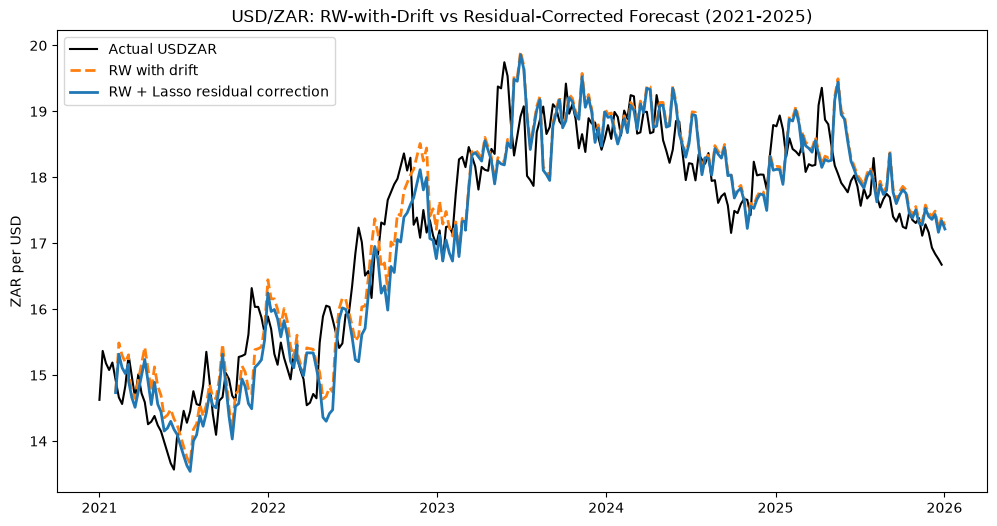

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price.loc['2021-01-01':'2025-12-31'].index, price.loc['2021-01-01':'2025-12-31'].values,
        label="Actual USDZAR", color="black", linewidth=1.5)
ax.plot(results_df['target_date'], results_df['rw_forecast'],
        label="RW with drift", color="tab:orange", linestyle='--', linewidth=2)
ax.plot(results_df['target_date'], results_df['combined_forecast'],
        label="RW + Lasso residual correction", color="tab:blue", linestyle='-', linewidth=2)
ax.legend()
ax.set_title("USD/ZAR: RW-with-Drift vs Residual-Corrected Forecast (2021-2025)")
ax.set_ylabel("ZAR per USD")
plt.show()